In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('E:/capstone/Adverstisement/advertising.csv')

In [3]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
df.shape

(200, 4)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
#if any drop by command df.drop_duplicates()

In [9]:
df.dtypes

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

In [10]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


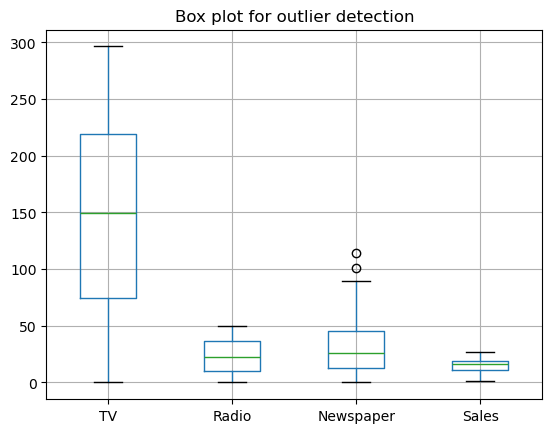

In [11]:
# To check outliers if any
import matplotlib.pyplot as plt

df.boxplot()
plt.title("Box plot for outlier detection")
plt.show()

##  M2: Descriptive Statistics

In [12]:
#print("Mean\n",df.mean())
#print("Median \n",df.median())
df.mean(),df.median()

(TV           147.0425
 Radio         23.2640
 Newspaper     30.5540
 Sales         15.1305
 dtype: float64,
 TV           149.75
 Radio         22.90
 Newspaper     25.75
 Sales         16.00
 dtype: float64)

In [13]:
print(df.corr())

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


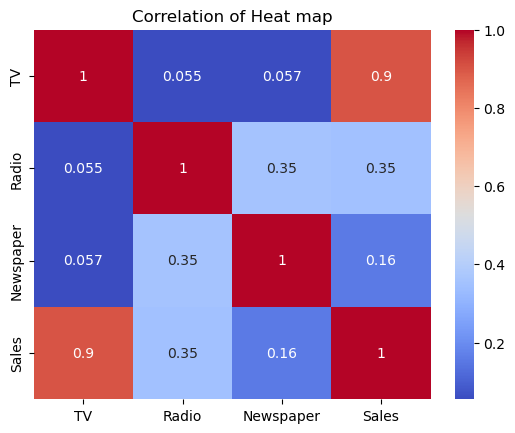

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap (df.corr(), annot= True, cmap='coolwarm')
plt.title("Correlation of Heat map")
plt.show()

In [31]:
df_corr = df.corr()["Sales"].sort_values(ascending=False)

In [30]:
df_corr

Sales        1.000000
TV           0.901208
Radio        0.349631
Newspaper    0.157960
Name: Sales, dtype: float64

In [34]:
df_corr = df.corr()['Sales'].drop('Sales').sort_values(ascending=False)

In [35]:
df_corr

TV           0.901208
Radio        0.349631
Newspaper    0.157960
Name: Sales, dtype: float64

## M3: Probability

In [37]:
sales_mean = df['Sales'].mean()
tv_mean = df['TV'].mean()


In [38]:
high_sales = df[df['Sales'] > sales_mean]
high_tv = df[df['TV'] > tv_mean]

In [39]:
high_sales

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
9,199.8,2.6,21.2,15.6
11,214.7,24.0,4.0,17.4
...,...,...,...,...
188,286.0,13.9,3.7,20.9
193,166.8,42.0,3.6,19.6
194,149.7,35.6,6.0,17.3
198,283.6,42.0,66.2,25.5


In [ ]:
## Probability of High Sales

In [41]:
## Probability of High Sales
p_high_sales = len(high_sales) / len(df)
print("P(High Sales):", round(p_high_sales, 2))

P(High Sales): 0.54


In [42]:
#Probability of High TV Advertising
p_high_tv = len(high_tv) / len(df)
print("P(High TV):", round(p_high_tv, 2))

P(High TV): 0.51


In [43]:
# Joint Probability
high_tv_sales = df[(df['TV'] > tv_mean) & (df['Sales'] > sales_mean )]

In [44]:
high_tv_sales

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
9,199.8,2.6,21.2,15.6
11,214.7,24.0,4.0,17.4
...,...,...,...,...
188,286.0,13.9,3.7,20.9
193,166.8,42.0,3.6,19.6
194,149.7,35.6,6.0,17.3
198,283.6,42.0,66.2,25.5


In [46]:
print("High Tv Advertisement and High Sales:", round( len(high_tv_sales)/len(df),2))

High Tv Advertisement and High Sales: 0.49


In [47]:
#Conditional Probability
p_conditional = len(high_tv_sales) / len(high_tv)
print("P(High Sales | High TV):", round(p_conditional, 2))

P(High Sales | High TV): 0.97


## M4: Statistical Inference

In [53]:
from scipy.stats import pearsonr

corr_tv,p_tv = pearsonr(df['TV'],df['Sales'])
print("TV Advertisements vs Sales")
print("Correlation:", round(corr_tv,2))
print("p-value:",round(p_tv,2))

TV Advertisements vs Sales
Correlation: 0.35
p-value: 0.0


In [54]:
corr_radio,p_radio = pearsonr(df['Radio'],df['Sales'])
print("Radio Advertisements vs Sales")
print("Correlation:", round(corr_radio,2))
print("p-value:",round(p_radio,2))

Radio Advertisements vs Sales
Correlation: 0.35
p-value: 0.0


In [55]:
corr_Newspaper,p_Newspaper = pearsonr(df['Newspaper'],df['Sales'])
print("Newspaper Advertisements vs Sales")
print("Correlation:", round(corr_Newspaper,2))
print("p-value:",round(p_Newspaper,2))

Newspaper Advertisements vs Sales
Correlation: 0.16
p-value: 0.03


In [59]:
alpha = 0.05

def decision(p):
    if p < alpha:
        return "Significant of Advertisement" 
    else:
        return " Not Significant of Advertisemet"

print("\n Decisions \n")
print("TV", decision(p_tv))
print("Radio",decision(p_radio))
print("Newspaper",decision(p_Newspaper))
      


 Decisions 

TV Significant of Advertisement
Radio Significant of Advertisement
Newspaper Significant of Advertisement


## M5: Regression

In [94]:
# ==============================
# M5: Multiple Linear Regression
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error


# Load dataset
#df = pd.read_csv('advertising.csv')

# Features and target
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model training
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test,y_pred)),2))
print("R2 Score:", round(r2_score(y_test, y_pred), 2))


MAE: 1.27
RMSE: 1.71
R2 Score: 0.91


In [79]:
# Prediction for new data
new_data = [[200, 30, 40]]
print("\nPredicted Sales:", model.predict(new_data)[0])



Predicted Sales: 18.81780731432812


In [84]:
import warnings
warnings.filterwarnings('ignore')


# Prediction for new data
new_data = [[200, 30, 40]]
print("\nPredicted Sales:", model.predict(new_data)[0])


Predicted Sales: 18.81780731432812


In [90]:
# ==============================
# M5: Multiple Linear Regression
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Load dataset
#df = pd.read_csv('advertising.csv')

# Features and target
X = df[['TV', 'Radio']]
y = df['Sales']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model training
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test,y_pred)),2))
print("R2 Score:", round(r2_score(y_test, y_pred), 2))


MAE: 1.27
RMSE: 1.69
R2 Score: 0.91


In [62]:
# Coefficients
#print("\nIntercept:", model.intercept_)
#print("Coefficients:")
#for feature, coef in zip(X.columns, model.coef_):
    #print(feature, ":", round(coef, 4))


In [87]:
# Prediction for new data
new_data = [[200, 30]]
print("\nPredicted Sales:", model.predict(new_data)[0])


Predicted Sales: 18.79058313908088



Predicted Sales: 18.81780731432812


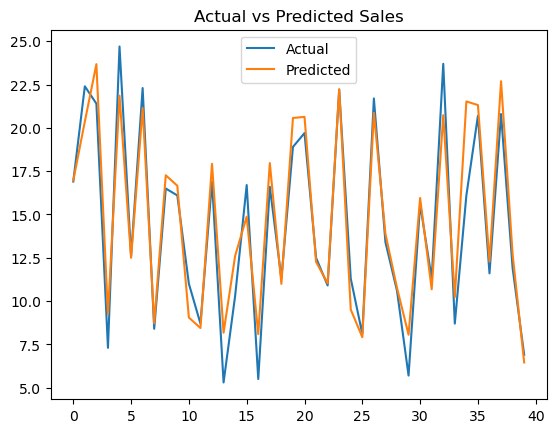

In [88]:
# Plot Actual vs Predicted
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [95]:
# ==============================
# M6: Interpretation & Conclusion
# ==============================

import pandas as pd

# ---- Correlation with Sales ----
corr = df.corr()['Sales'].drop('Sales')

print("🔹 Correlation with Sales:")
print(corr, "\n")

# ---- Identify strongest feature ----
best_feature = corr.idxmax()
weak_feature = corr.idxmin()

# ---- Print Interpretation ----
print("🔹 Interpretation:")

print(f"- {best_feature} has the strongest impact on Sales.")
print(f"- {weak_feature} has the weakest impact on Sales.\n")

# ---- Model Performance ----
print("🔹 Model Performance:")
print(f"- MAE: {round(mean_absolute_error(y_test, y_pred),2)}")
print(f"- RMSE: {round(np.sqrt(mean_squared_error(y_test, y_pred)),2)}")
print(f"- R2 Score: {round(r2_score(y_test, y_pred),2)}\n")

# ---- Business Insight ----
print("🔹 Business Insight:")
print(f"- Increase investment in {best_feature} advertising.")
print("- Use other channels as support.")
print(f"- Reduce focus on {weak_feature} advertising.\n")

# ---- Final Conclusion ----
print("🔹 Final Conclusion:")
print("Advertising has a positive impact on sales.")
print(f"{best_feature} is the most effective medium.")
print(f"{weak_feature} has minimal effect.")

🔹 Correlation with Sales:
TV           0.901208
Radio        0.349631
Newspaper    0.157960
Name: Sales, dtype: float64 

🔹 Interpretation:
- TV has the strongest impact on Sales.
- Newspaper has the weakest impact on Sales.

🔹 Model Performance:
- MAE: 1.27
- RMSE: 1.71
- R2 Score: 0.91

🔹 Business Insight:
- Increase investment in TV advertising.
- Use other channels as support.
- Reduce focus on Newspaper advertising.

🔹 Final Conclusion:
Advertising has a positive impact on sales.
TV is the most effective medium.
Newspaper has minimal effect.


In [97]:
# ==============================
# M6: Interpretation with p-value
# ==============================

from scipy.stats import pearsonr

features = ['TV', 'Radio', 'Newspaper']

print("🔹 Detailed Interpretation:\n")

for feature in features:
    corr, p = pearsonr(df[feature], df['Sales'])
    
    print(f"{feature}:")
    print(f"  Correlation = {round(corr,2)}")
    print(f"  p-value = {p}")
    
    if p < 0.05:
        if abs(corr) > 0.5:
            print("  ➤ Strong & Significant impact ✔️")
        elif abs(corr) > 0.3:
            print("  ➤ Moderate & Significant impact ✔️")
        else:
            print("  ➤ Weak but Significant impact ⚠️")
    else:
        print("  ➤ Not Significant ❌")
    
    print()

🔹 Detailed Interpretation:

TV:
  Correlation = 0.9
  p-value = 7.92791162532114e-74
  ➤ Strong & Significant impact ✔️

Radio:
  Correlation = 0.35
  p-value = 3.8828923644941284e-07
  ➤ Moderate & Significant impact ✔️

Newspaper:
  Correlation = 0.16
  p-value = 0.025487444306996235
  ➤ Weak but Significant impact ⚠️



In [98]:
# ==============================
# M6: Interpretation & Conclusion (Final)
# ==============================

import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- Correlation with Sales ----
corr_series = df.corr()['Sales'].drop('Sales')

print("🔹 Correlation with Sales:")
print(corr_series, "\n")

# ---- Identify strongest & weakest ----
best_feature = corr_series.idxmax()
weak_feature = corr_series.idxmin()

# ---- Detailed Interpretation with p-values ----
print("🔹 Detailed Interpretation (with p-value):\n")

features = ['TV', 'Radio', 'Newspaper']

for feature in features:
    corr, p = pearsonr(df[feature], df['Sales'])
    
    print(f"{feature}:")
    print(f"  Correlation = {round(corr,2)}")
    print(f"  p-value = {p}")
    
    if p < 0.05:
        if abs(corr) > 0.5:
            print("  ➤ Strong & Significant impact ✔️")
        elif abs(corr) > 0.3:
            print("  ➤ Moderate & Significant impact ✔️")
        else:
            print("  ➤ Weak but Significant impact ⚠️")
    else:
        print("  ➤ Not Significant ❌")
    
    print()

# ---- Model Performance ----
print("🔹 Model Performance:")
print(f"- MAE: {round(mean_absolute_error(y_test, y_pred),2)}")
print(f"- RMSE: {round(np.sqrt(mean_squared_error(y_test, y_pred)),2)}")
print(f"- R2 Score: {round(r2_score(y_test, y_pred),2)}\n")

# ---- Business Insight ----
print("🔹 Business Insight:")
print(f"- Increase investment in {best_feature} advertising.")
print("- Use other channels as support.")
print(f"- Reduce focus on {weak_feature} advertising.\n")

# ---- Final Conclusion ----
print("🔹 Final Conclusion:")
print("Advertising has a positive impact on sales.")
print(f"{best_feature} is the most effective medium.")
print(f"{weak_feature} has minimal effect.")

🔹 Correlation with Sales:
TV           0.901208
Radio        0.349631
Newspaper    0.157960
Name: Sales, dtype: float64 

🔹 Detailed Interpretation (with p-value):

TV:
  Correlation = 0.9
  p-value = 7.92791162532114e-74
  ➤ Strong & Significant impact ✔️

Radio:
  Correlation = 0.35
  p-value = 3.8828923644941284e-07
  ➤ Moderate & Significant impact ✔️

Newspaper:
  Correlation = 0.16
  p-value = 0.025487444306996235
  ➤ Weak but Significant impact ⚠️

🔹 Model Performance:
- MAE: 1.27
- RMSE: 1.71
- R2 Score: 0.91

🔹 Business Insight:
- Increase investment in TV advertising.
- Use other channels as support.
- Reduce focus on Newspaper advertising.

🔹 Final Conclusion:
Advertising has a positive impact on sales.
TV is the most effective medium.
Newspaper has minimal effect.
